Binary Logistic Regression Analyis

load data

In [2]:
import pandas as pd
db=pd.read_csv("Diabetes_data (3).csv")
db.head()

,BMI,diabetes,cholesterol,sbp,age,smoking,gender,obesity_status,obesity
0,16.71,0,168,83.5,35,Smoker,F,0,Non obese
1,16.73,0,213,125.0,39,Nonsmoker,F,0,Non obese
2,16.75,0,224,117.0,45,Smoker,F,0,Non obese
3,16.87,0,184,107.0,47,Smoker,M,0,Non obese
4,16.92,0,222,146.0,63,Nonsmoker,F,0,Non obese


Fitting Simple Binary  logisctic regression model

Example Fit a model to assess the the relationship between developing coronary heart disease(CHD) and body mass index(BMI)

In [3]:
import statsmodels.formula.api as smf
binlog_reg = smf.logit(formula = 'diabetes ~ BMI', data = db).fit()
binlog_reg.summary()

Optimization terminated successfully.
         Current function value: 0.086425
         Iterations 11


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               diabetes   No. Observations:                  717
Model:                          Logit   Df Residuals:                      715
Method:                           MLE   Df Model:                            1
Date:                Fri, 14 Aug 2026   Pseudo R-squ.:                  0.6125
Time:                        16:22:16   Log-Likelihood:                -61.967
converged:                       True   LL-Null:                       -159.92
Covariance Type:            nonrobust   LLR p-value:                 1.640e-44
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -57.6820      8.658     -6.662      0.000     -74.652     -40.712
BMI            1.8467      0.289      6.392      0.000       1.280       2.413
==============================================================================

Possibly complete quasi-separation: A fraction 0.38 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

to get odds ratio and 95% confidence interval for odds ratio

In [4]:
import numpy as np
binlog_results = pd.DataFrame(
    {
        "OR": binlog_reg.params,
        "Lower CI": binlog_reg.conf_int()[0],
        "Upper CI": binlog_reg.conf_int()[1],
    }
)
binlog_results = np.exp(binlog_results)

print(binlog_results)

                     OR      Lower CI      Upper CI
Intercept  8.892693e-26  3.794046e-33  2.084318e-18
BMI        6.338776e+00  3.598093e+00  1.116705e+01


Prediction of outcome:

extract the coefficient estimates of fiited model to find the sigmod function and hence the estimated probability of outcome


In [5]:
# the parameter estimates to be used to estimate the probability
binlog_reg.params

Intercept   -57.681983
BMI           1.846686
dtype: float64

Noe predict status of an individual with BMI of 29.5

In [6]:
#manually obtain the estimated probability, calculate the numerator and denominator using formula
# for the sigmod function
#value= intercept +(gradient* specified value of independent variable)
#nm=exp(-value)
#function is 1/(1+nm)
value=-57.681983+(1.846686*29.5)
nm=np.exp(-value)
#estimated probability is equal to numerator/ denominator
est_prob=1/(1+nm)
print(round(est_prob,2))

0.04


Fitting Multiple Binary logistic regression model

In [7]:
db["smk"]=pd.get_dummies(db['smoking'], dtype=int,drop_first=True)
db.head()

,BMI,diabetes,cholesterol,sbp,age,smoking,gender,obesity_status,obesity,smk
0,16.71,0,168,83.5,35,Smoker,F,0,Non obese,1
1,16.73,0,213,125.0,39,Nonsmoker,F,0,Non obese,0
2,16.75,0,224,117.0,45,Smoker,F,0,Non obese,1
3,16.87,0,184,107.0,47,Smoker,M,0,Non obese,1
4,16.92,0,222,146.0,63,Nonsmoker,F,0,Non obese,0


In [8]:
multlog_reg = smf.logit(formula = 'diabetes ~ sbp+BMI+smk', data = db).fit()
multlog_reg.summary()

Optimization terminated successfully.
         Current function value: 0.072643
         Iterations 11


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               diabetes   No. Observations:                  717
Model:                          Logit   Df Residuals:                      713
Method:                           MLE   Df Model:                            3
Date:                Fri, 14 Aug 2026   Pseudo R-squ.:                  0.6743
Time:                        16:22:39   Log-Likelihood:                -52.085
converged:                       True   LL-Null:                       -159.92
Covariance Type:            nonrobust   LLR p-value:                 1.739e-46
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -63.1369     10.053     -6.281      0.000     -82.839     -43.434
sbp            0.0443      0.012      3.844      0.000       0.022       0.067
BMI            1.7819      0.317      5.618      0.000       1.160       2.404
smk            1.2778      0.593      2.153      0.031       0.115       2.441
==============================================================================

Possibly complete quasi-separation: A fraction 0.38 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

to get odds ratio and 95% confidence interval for odds ratio

In [9]:
import numpy as np
multlog_results = pd.DataFrame(
    {
        "OR": multlog_reg.params,
        "Lower CI": multlog_reg.conf_int()[0],
        "Upper CI": multlog_reg.conf_int()[1],
    }
)
multlog_results = np.exp(multlog_results)

print(multlog_results)

                     OR      Lower CI      Upper CI
Intercept  3.801749e-28  1.055028e-36  1.369944e-19
sbp        1.045273e+00  1.021940e+00  1.069140e+00
BMI        5.941234e+00  3.190638e+00  1.106307e+01
smk        3.588877e+00  1.121685e+00  1.148276e+01


Predict status for an individual with systolic blood pressure(sbp)of 190, smokes and has BMI of 32.1

In [10]:
multlog_reg.params

Intercept   -63.136921
sbp           0.044278
BMI           1.781917
smk           1.277839
dtype: float64

In [11]:
#manually obtain the estimated probability, calculate the numerator and denominator using formula
# for the sigmod function
value=-63.136921+(0.044278*190)+(1.781917*32.1)+(1.277839*1)
nm=np.exp(-value)
#estimated probability is equal to numerator/ denominator
est_prob=1/(1+nm)
print(round(est_prob,2))

0.98


Evaluation of fitted model:

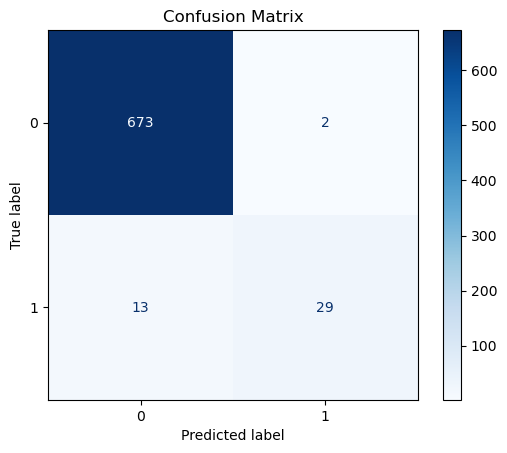

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Classify using threshold of 0.5
diabetes_predict=multlog_reg.predict(db)
# Classify using threshold of 0.5
diabetes_predicted_classes = [1 if prob >= 0.5 else 0 for prob in diabetes_predict]
#confusion matrix
cm = confusion_matrix(db['diabetes'], diabetes_predicted_classes)
# Display it as a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [13]:
#metrics

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


accuracy = accuracy_score(db['diabetes'], diabetes_predicted_classes)

# Precision
precision = precision_score(db['diabetes'], diabetes_predicted_classes)

# Recall
recall = recall_score(db['diabetes'], diabetes_predicted_classes)

# Display results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.98
Precision: 0.94
Recall: 0.69


Activity on cholera outbreak